In [1]:
"""
This code sets up the necessary libraries and configurations for data analysis and visualization in a Jupyter Notebook 
environment.

The following libraries are imported:
- pandas: for data manipulation and analysis
- matplotlib.pyplot: for creating static visualizations
- numpy: for numerical operations
- seaborn: for creating attractive and informative statistical graphics

The %matplotlib inline command is used to display the plots directly in the notebook, rather than in a separate window.
"""
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
%matplotlib inline

In [2]:
"""
Reads in two datasets from local files:
- `purch_behavior`: a CSV file containing purchase behavior data
- `transaction`: an Excel file containing transaction data

These datasets are likely used for further analysis and modeling in the notebook.
"""
purch_behavior=pd.read_csv(r'C:\Users\HP\Downloads\QVI_purchase_behaviour.csv')
transaction= pd.read_excel(r"C:\Users\HP\Downloads\QVI_transaction_data.xlsx")

In [3]:
"""
Displays the first 5 rows of the `purch_behavior` DataFrame.

This function is useful for quickly inspecting the structure and contents of the `purch_behavior` DataFrame,
 which contains the data related to customer purchasing behavior.
"""
purch_behavior.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [4]:
"""
Displays the first 5 rows of the `transaction` DataFrame.

This method is useful for quickly inspecting the structure and contents of the DataFrame,
especially when working with large datasets.
"""
transaction.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [5]:
"""
Generates descriptive statistics for the `purch_behavior` DataFrame, 
including the count, mean, standard deviation, minimum, 25th percentile, median, 75th percentile, 
and maximum for each column.

This function provides a high-level overview of the data in the `purch_behavior` DataFrame, 
which can be useful for understanding the distribution and characteristics of the variables.
"""
purch_behavior.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [6]:
'''Provides a summary of the statistical properties of the `transaction` DataFrame,
 including the count, mean, standard deviation, minimum, and maximum values for each numeric column.'''
transaction.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [7]:
"""
Merge the 'purch_behavior' and 'transaction' DataFrames on the 'LYLTY_CARD_NBR' column, using an outer join. 
This will create a new DataFrame 'merged_df' that contains all the rows from both DataFrames, 
with any missing values filled in.

The resulting 'merged_df' DataFrame can be used for further analysis and insights
into customer purchase behavior and transactions.
"""
merged_df= pd.merge(purch_behavior, transaction, on='LYLTY_CARD_NBR', how= 'outer')
merged_df.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,1000,YOUNG SINGLES/COUPLES,Premium,43390,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,1002,YOUNG SINGLES/COUPLES,Mainstream,43359,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7
2,1003,YOUNG FAMILIES,Budget,43531,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6
3,1003,YOUNG FAMILIES,Budget,43532,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0
4,1004,OLDER SINGLES/COUPLES,Mainstream,43406,1,5,96,WW Original Stacked Chips 160g,1,1.9


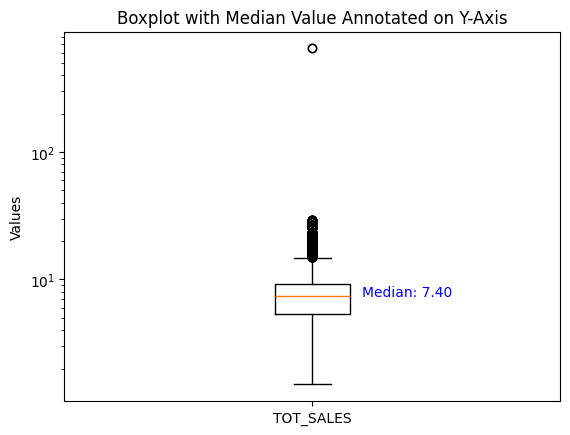

In [8]:
"""
Generates a box plot for the 'TOT_SALES' column in the `merged_df` DataFrame, and sets the y-axis scale to logarithmic.

The box plot provides a visual representation of the distribution of the 'TOT_SALES' values, including the median,
quartiles, and any outliers. 
The logarithmic scale is used to better visualize the data, as sales values can span a wide range.
"""

median_value = np.median(merged_df['TOT_SALES'])

# Plot the boxplot
plt.boxplot(merged_df['TOT_SALES'], tick_labels =['TOT_SALES'])

# Annotating the median value on the Y-axis
plt.text(x=1.1, y=median_value, s=f'Median: {median_value:.2f}', color='blue')

# Additional plot settings
plt.title("Boxplot with Median Value Annotated on Y-Axis")
plt.ylabel("Values")
plt.yscale('log')
plt.show()

In [9]:
"""
Generates a statistical summary of the `merged_df` DataFrame, including the count, 
mean, standard deviation, minimum, 
25th percentile, median, 75th percentile, and maximum for each column.

This provides a high-level overview of the data in the DataFrame, 
which can be useful for understanding the distribution and characteristics of the variables.
"""
merged_df.describe()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,2.648360e+05,264836.000000,264836.00000,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,1.355495e+05,43464.036260,135.08011,1.351583e+05,56.583157,1.907309,7.304200
std,8.057998e+04,105.389282,76.78418,7.813303e+04,32.826638,0.643654,3.083226
min,1.000000e+03,43282.000000,1.00000,1.000000e+00,1.000000,1.000000,1.500000
25%,7.002100e+04,43373.000000,70.00000,6.760150e+04,28.000000,2.000000,5.400000
50%,1.303575e+05,43464.000000,130.00000,1.351375e+05,56.000000,2.000000,7.400000
75%,2.030942e+05,43555.000000,203.00000,2.027012e+05,85.000000,2.000000,9.200000
max,2.373711e+06,43646.000000,272.00000,2.415841e+06,114.000000,200.000000,650.000000


In [10]:
"""
Calculates and returns summary statistics for the 'TOT_SALES' column in the 'merged_df' DataFrame. 
This includes the count, mean, standard deviation, minimum, 25th percentile, median, 75th percentile,
and maximum values for the 'TOT_SALES' column.

Returns:
    pandas.Series: A Series containing the summary statistics for the 'TOT_SALES' column.
"""
merged_df['TOT_SALES'].describe()

count    264836.000000
mean          7.304200
std           3.083226
min           1.500000
25%           5.400000
50%           7.400000
75%           9.200000
max         650.000000
Name: TOT_SALES, dtype: float64

In [ ]:
"""
Describes the outlier data in the given numeric columns of the `merged_df` DataFrame.

This function calculates the upper and lower limits for each numeric column based on the mean and standard deviation. 
It then identifies the outliers and creates a new DataFrame `cleaned_df` with the outliers removed. 
Finally, it generates visualizations (box plot, histogram, and kernel density plot) of the cleaned data 
for each numeric column.

Args:
    numerics (dict): A dictionary where the keys are the column names and the values are the corresponding numeric columns 
    from the `merged_df` DataFrame.

Returns:
    cleaned_df (pandas.DataFrame): A new DataFrame with the outliers removed.
"""
#using Z score method to remove outliers of the total sales 

def describe_outlier_data(numerics)->list :
    for i, j in numerics: #where i and j make up a tuple which is placed inside the list. 
                          #"i" is the name assigned to the column
                          #j is the column itself containing numerical values 
        #finding the upper and lower limits 
        upper_limit= j.mean() + 3*j.std() #3 standard deviations after the mean
        lower_limit= j.mean() - 3*j.std() #3 standard deviations before the mean
        print(f'upper limit of {i}:', upper_limit)9
        print(f'lower limit of {i}:', lower_limit)

        #To find the outliers
        outlier_df= merged_df.loc[(j>upper_limit)|(j<lower_limit)]

        #Now to trim out the outlier data
        cleaned_df=merged_df.loc[(j<upper_limit)&(j>lower_limit)]
        print(f'length of the dataframe before removing outliers of {i} is {len(merged_df)}')
        print(f'length of the dataframe after removing outliers of {i} is {len(cleaned_df)}')

        # To further visualize the cleaner data
        plt.figure(figsize=(15, 6))

        # Box plot
        clean_median_value=np.median(j)
        plt.subplot(1, 3, 1)
        plt.boxplot(cleaned_df[j.name])
        plt.title(f'Box plot of {i} after removing outliers')
        plt.xlabel(i)
        plt.ylabel('Values')
        # Annotate the median on the plot
        plt.text(1.1, clean_median_value, f'Median: {clean_median_value:.2f}', color='red', ha='center')

        # Histogram
        plt.subplot(1, 3, 2)
        plt.hist(cleaned_df[j.name], bins=30, edgecolor='black')
        plt.title(f'Histogram of {i} after removing outliers')
        plt.xlabel(i)
        plt.ylabel('Frequency')

        #Kernel Density Plot
        # Kernel Density Plot
        plt.subplot(1, 3, 3)
        sns.kdeplot(cleaned_df[j.name], fill=True)
        plt.title(f'Kernel Density Plot of {i} after removing outliers')
        plt.xlabel(i)
        plt.ylabel('Density')

        plt.tight_layout()
        plt.show()
    return cleaned_df

In [12]:
"""
Displays the first 5 rows of the `purch_behavior` DataFrame.

This function is useful for quickly inspecting the structure and contents of the `purch_behavior` DataFrame, which likely contains data related to customer purchasing behavior.
"""
purch_behavior.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


upper limit of TOTAL SALES: 16.553876818817134
lower limit of TOTAL SALES: -1.9454776585821243
length of the dataframe before removing outliers of TOTAL SALES is 264836
length of the dataframe after removing outliers of TOTAL SALES is 264397


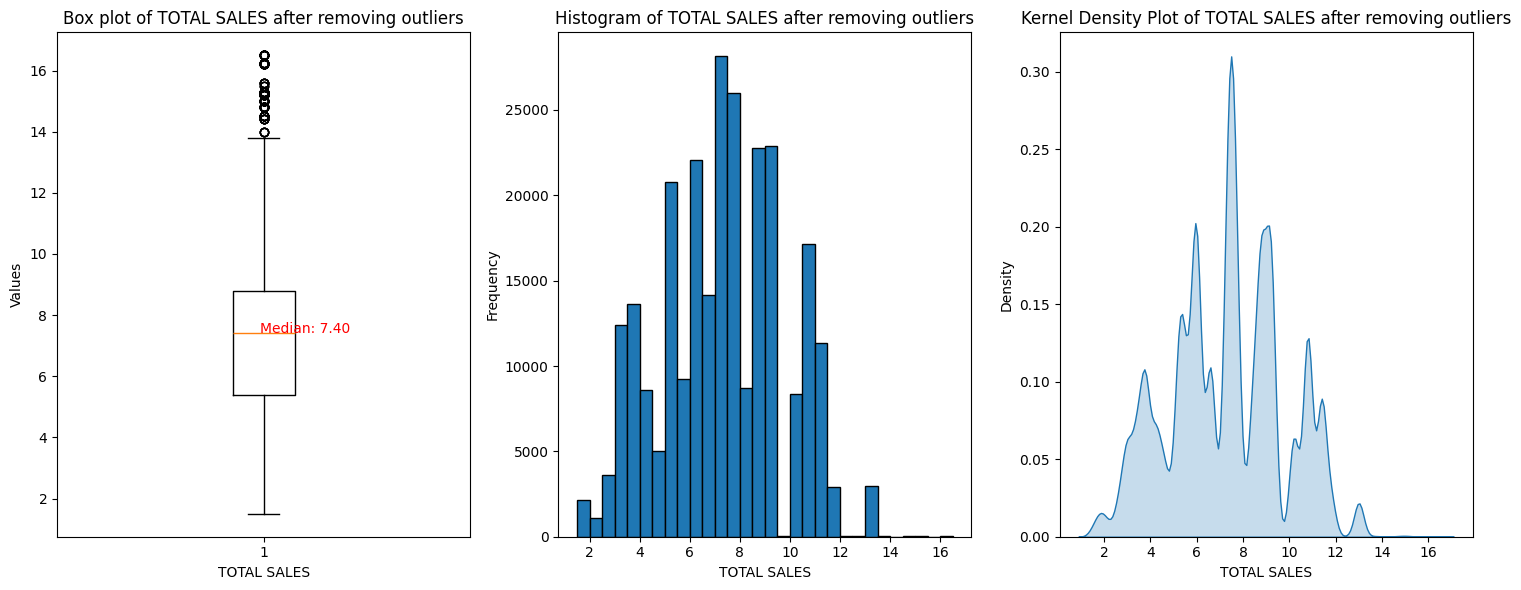

In [13]:
"""
Calculates the total sales from the `merged_df` DataFrame and passes them to the `describe_outlier_data` function.

Args:
    merged_df (pandas.DataFrame): The DataFrame containing the sales data.

Returns:
    pandas.DataFrame: The DataFrame with the outlier data described.
"""
SALES= [('TOTAL SALES', merged_df['TOT_SALES'])]

cleaned_df=describe_outlier_data(SALES)

In [14]:
cleaned_df.describe()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,2.643970e+05,264397.000000,264397.000000,2.643970e+05,264397.000000,264397.000000,264397.000000
mean,1.355439e+05,43464.043022,135.073999,1.351525e+05,56.588706,1.901523,7.276687
std,8.058948e+04,105.330050,76.787664,7.813661e+04,32.825008,0.326093,2.463343
min,1.000000e+03,43282.000000,1.000000,1.000000e+00,1.000000,1.000000,1.500000
25%,7.001900e+04,43373.000000,70.000000,6.759100e+04,28.000000,2.000000,5.400000
50%,1.303550e+05,43464.000000,130.000000,1.351300e+05,56.000000,2.000000,7.400000
75%,2.030940e+05,43555.000000,203.000000,2.027010e+05,85.000000,2.000000,8.800000
max,2.373711e+06,43646.000000,272.000000,2.415841e+06,114.000000,5.000000,16.500000


In [15]:
"""
Prints the unique categories in the 'LIFESTAGE' and 'PREMIUM_CUSTOMER' columns of the 'cleaned_df' DataFrame.

This code is used to explore the data by displaying the unique values present in these categorical columns. 
It can help understand the distribution and characteristics of the data.
"""
discrete_columns=['LIFESTAGE', 'PREMIUM_CUSTOMER']
for i in discrete_columns:
    print(f'unique categories in {i} are:  {cleaned_df[i].unique().astype(str)}')

unique categories in LIFESTAGE are:  ['YOUNG SINGLES/COUPLES' 'YOUNG FAMILIES' 'OLDER SINGLES/COUPLES'
 'MIDAGE SINGLES/COUPLES' 'NEW FAMILIES' 'OLDER FAMILIES' 'RETIREES']
unique categories in PREMIUM_CUSTOMER are:  ['Premium' 'Mainstream' 'Budget']


In [16]:
# TOTAL SALES
Rounded_total_sales=round(cleaned_df['TOT_SALES'].sum(), 2)
print(f'Total sales in the cleaned data is {Rounded_total_sales}')

Total sales in the cleaned data is 1923934.1


In [17]:
cleaned_df.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,1000,YOUNG SINGLES/COUPLES,Premium,43390,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,1002,YOUNG SINGLES/COUPLES,Mainstream,43359,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7
2,1003,YOUNG FAMILIES,Budget,43531,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6
3,1003,YOUNG FAMILIES,Budget,43532,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0
4,1004,OLDER SINGLES/COUPLES,Mainstream,43406,1,5,96,WW Original Stacked Chips 160g,1,1.9


C:\Users\HP\AppData\Local\Temp\ipykernel_18272\3082207943.py:11: FutureWarning: The provided callable <function sum at 0x0000019B57E4CC20> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  drivers=cleaned_df.groupby(i)['TOT_SALES'].agg(np.sum).sort_values(ascending=False)


LIFESTAGE
OLDER SINGLES/COUPLES     400324.45
RETIREES                  364868.00
OLDER FAMILIES            350423.80
YOUNG FAMILIES            314595.30
YOUNG SINGLES/COUPLES     259558.20
MIDAGE SINGLES/COUPLES    183863.50
NEW FAMILIES               50300.85
Name: TOT_SALES, dtype: float64


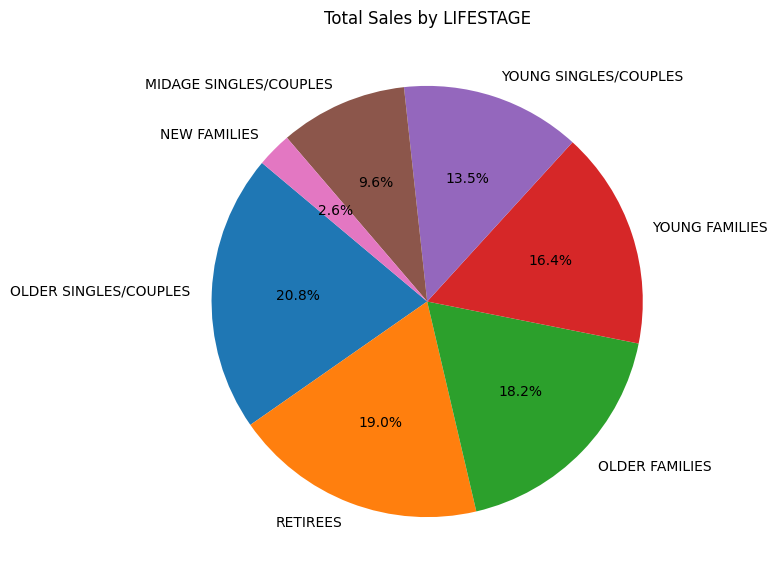

PREMIUM_CUSTOMER
Mainstream    747321.70
Budget        672784.05
Premium       503828.35
Name: TOT_SALES, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_18272\3082207943.py:11: FutureWarning: The provided callable <function sum at 0x0000019B57E4CC20> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  drivers=cleaned_df.groupby(i)['TOT_SALES'].agg(np.sum).sort_values(ascending=False)


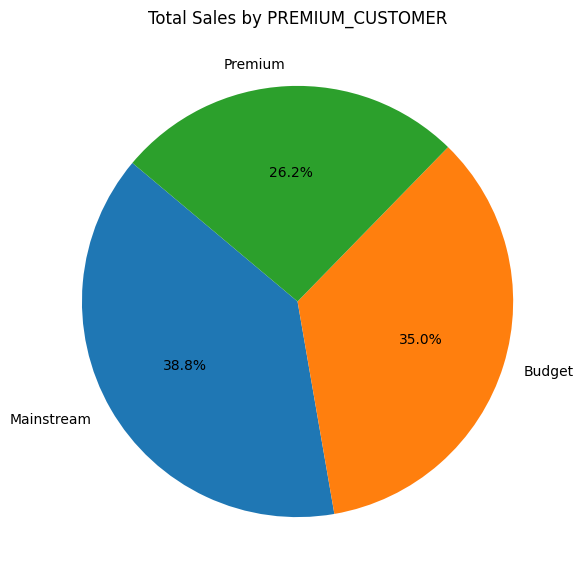

PROD_QTY
2    1811775.20
1     102220.00
3       4405.05
4       2930.20
5       2603.65
Name: TOT_SALES, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_18272\3082207943.py:11: FutureWarning: The provided callable <function sum at 0x0000019B57E4CC20> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  drivers=cleaned_df.groupby(i)['TOT_SALES'].agg(np.sum).sort_values(ascending=False)


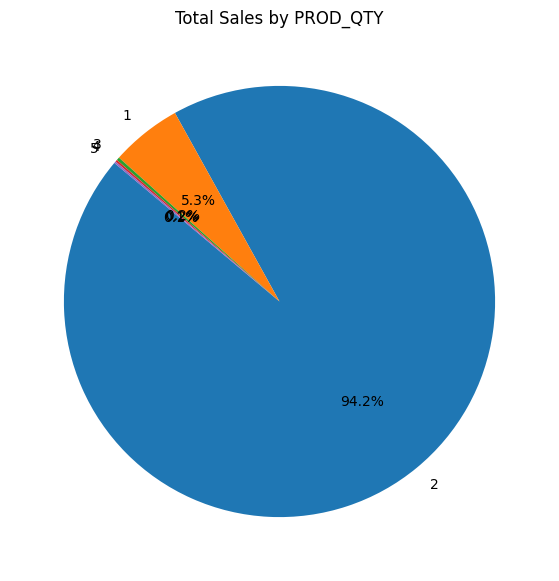

In [18]:
"""
Generates pie charts to visualize the total sales by different categories in the 'cleaned_df' DataFrame.

The categories analyzed are 'LIFESTAGE', 'PREMIUM_CUSTOMER', and 'PROD_QTY'. 
For each category, the total sales are aggregated and sorted in descending order. 
A pie chart is then generated to display the percentage contribution of each category to the total sales.
"""
categories = ['LIFESTAGE','PREMIUM_CUSTOMER', 'PROD_QTY']   
for i in categories:
    # Group by category and aggregate 'TOT_SALES' by sum
    drivers=cleaned_df.groupby(i)['TOT_SALES'].agg(np.sum).sort_values(ascending=False)
    print(drivers)

    # Plot the pie chart
    plt.figure(figsize=(12, 7))
    plt.pie(drivers, labels=drivers.index, autopct='%1.1f%%', startangle=140)
    plt.title(f'Total Sales by {i}')
    plt.show()

From above, we can see that:
1. The Driver of sales by Lifestage is the 'OLDER SINGLES/COUPLES category
2. Driver of sales by Premium Customer is the 'Mainstream' category
3. Driver of sales by Product qunatity is the category of 2 


